In [93]:
filepath = r'C:\Users\User\Online_retail_analysis\Online_Retail_csv.csv'

import pandas as pd
import numpy as np
df = pd.read_csv(filepath)



In [94]:
clean_df = df[['StockCode','UnitPrice']].dropna()
clean_df = df[df['UnitPrice'] > 0]
stock_prices_dict = dict(zip(clean_df.StockCode, clean_df.UnitPrice))



In [95]:
df['UnitPrice'] = df.StockCode.map(stock_prices_dict)


In [ ]:
#prices_above = [i for i in stock_prices_hash.values() if i < 5]
#print(np.mean(prices_above))

#print(len(df.StockCode.unique()))

In [97]:
'''Build the hashmap of stockcode: description where description is all uppercase and len is above 1.
then map it to all other descriptions.
filter out all the descriptions that are not uppercases.
fix those descriptions
ORRRR
since we have fixed prices, do we just find outliers and fix that dataset?
description is not all that important, it is required to gauge which returns are actual returns.
So we can do the following,
1: find ouliers for negative quantities.
2: see if there is a problem with descriptions.'''

'Build the hashmap of stockcode: description where description is all uppercase and len is above 1.\nthen map it to all other descriptions.\nfilter out all the descriptions that are not uppercases.\nfix those descriptions\nORRRR\nsince we have fixed prices, do we just find outliers and fix that dataset?\ndescription is not all that important, it is required to gauge which returns are actual returns.\nSo we can do the following,\n1: find ouliers for negative quantities.\n2: see if there is a problem with descriptions.'

In [98]:
#Fishing_out outliers

df_neg = df[df['Quantity'] <= 0]
df_pos = df[df['Quantity'] > 0]

upper_bound_quantity = np.quantile(df.Quantity, 0.75)
lower_bound_quantity = np.quantile(df.Quantity, 0.25)
upper_bound_price = np.quantile(df.UnitPrice, 0.75)
lower_bound_price = np.quantile(df.UnitPrice, 0.25)

quantity_iqr = upper_bound_quantity - lower_bound_quantity
price_iqr = upper_bound_price - lower_bound_price

#print(f' quantity negatives are {len(df[df['Quantity'] < 0] )}')
#print(f' unit price negatives are {len(df[df['UnitPrice'] < 0])}')


In [99]:
df.info()
#description_caps = [str(i) for i in df['Description'].str.strip if all(i.upper())]



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541775 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


In [100]:
df['date'] = pd.to_datetime(df.InvoiceDate, errors = 'coerce').dt.date
df['date'] = pd.to_datetime(df['date'], errors = 'coerce')

print(f'minimum is {df['date'].min()}, maximum is {df['date'].max()} ')

neg_quantity = df.loc[lambda x: x['Quantity'] < 0, :]
def validating_false_positive():
    valid_df = df[np.logical_and(df['Quantity'] < 0, df['UnitPrice'] < 0)]
    print(valid_df.shape[0])

validating_false_positive()



minimum is 2010-12-01 00:00:00, maximum is 2011-12-09 00:00:00 
0


In [101]:
df['Revenue'] = (df['Quantity'] * df['UnitPrice']).round(3)

df['Revenue'].describe()
df['Month'] = df['date'].dt.month

revenue_per_month = df.groupby('Month')['Revenue'].sum().reset_index()
months = ['January','February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', \
'October', 'November', 'December']
months_keys = [i for i in range(1,13)]
months_dict = dict(zip(months_keys, months))

df['Month'] = df['date'].dt.month.map(months_dict)
df['Month'] = df.Month.astype('category')
df['Month'] = df['Month'].cat.set_categories(new_categories= months, ordered= True)
print(df.Month)


0         December
1         December
2         December
3         December
4         December
            ...   
541904    December
541905    December
541906    December
541907    December
541908    December
Name: Month, Length: 541909, dtype: category
Categories (12, object): ['January' < 'February' < 'March' < 'April' ... 'September' < 'October' < 'November' < 'December']


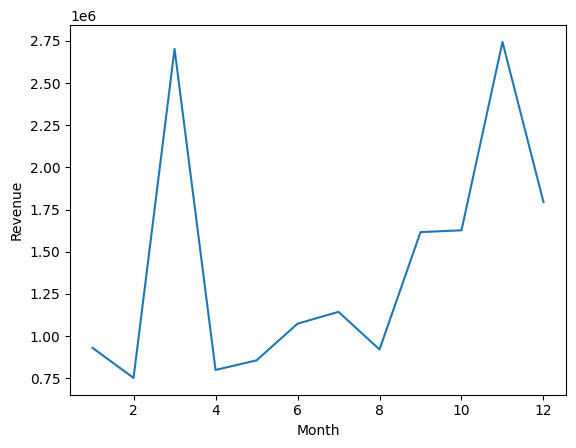

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data = revenue_per_month, x= 'Month', y= 'Revenue')
plt.show()

In [105]:
month_revenue = df.groupby('Month')['Revenue'].sum().round(2).reset_index()

C:\Users\User\AppData\Local\Temp\ipykernel_1524\1553091746.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_revenue = df.groupby('Month')['Revenue'].sum().round(2).reset_index()


In [ ]:
month_returns_per_country = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Month', 'Country'])['Revenue'].sum().round(2).reset_index()

C:\Users\User\AppData\Local\Temp\ipykernel_1524\1690014145.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_returns = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Month', 'Country'])['Revenue'].sum().round(2).reset_index()


In [119]:
#purchases no. per country
purchases_per_country = df.Country.value_counts().to_dict()
returns_per_country = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Country'])['Revenue'].sum().round(2).reset_index()
returns_per_country_2 = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Country'])['Revenue'].sum().round(2).to_dict()
countries_that_returned = list(returns_per_country.Country)
returns_per_purchases = returns_per_country.loc[lambda x: x['Country'] == countries_that_returned]

returns_per_purchases['UnitsSold'] = returns_per_purchases.Country.map(returns_per_country_2)